In [27]:
import numpy as np
from PIL import Image
import cv2

img = Image.open(r"C:\Users\krish\Downloads\TrueFit Vision\Shirt3-C44cm L57cm.jpg")

if img.width > img.height:
    img = img.rotate(-90, expand=True)
    print("Rotated PIL image to portrait")

image_cv = cv2.cvtColor(np.array(img), cv2.COLOR_RGB2BGR)
gray = cv2.cvtColor(image_cv, cv2.COLOR_BGR2GRAY)

print("Final size:", img.size)

Final size: (1278, 1600)


In [1]:
!pip install transformers torch pillow numpy
!pip install torchvision
!pip install opencv-python


In [28]:
from transformers import pipeline

segmenter = pipeline(model="mattmdjaga/segformer_b2_clothes")
segments = segmenter(img)

Loading weights:   0%|          | 0/380 [00:00<?, ?it/s]

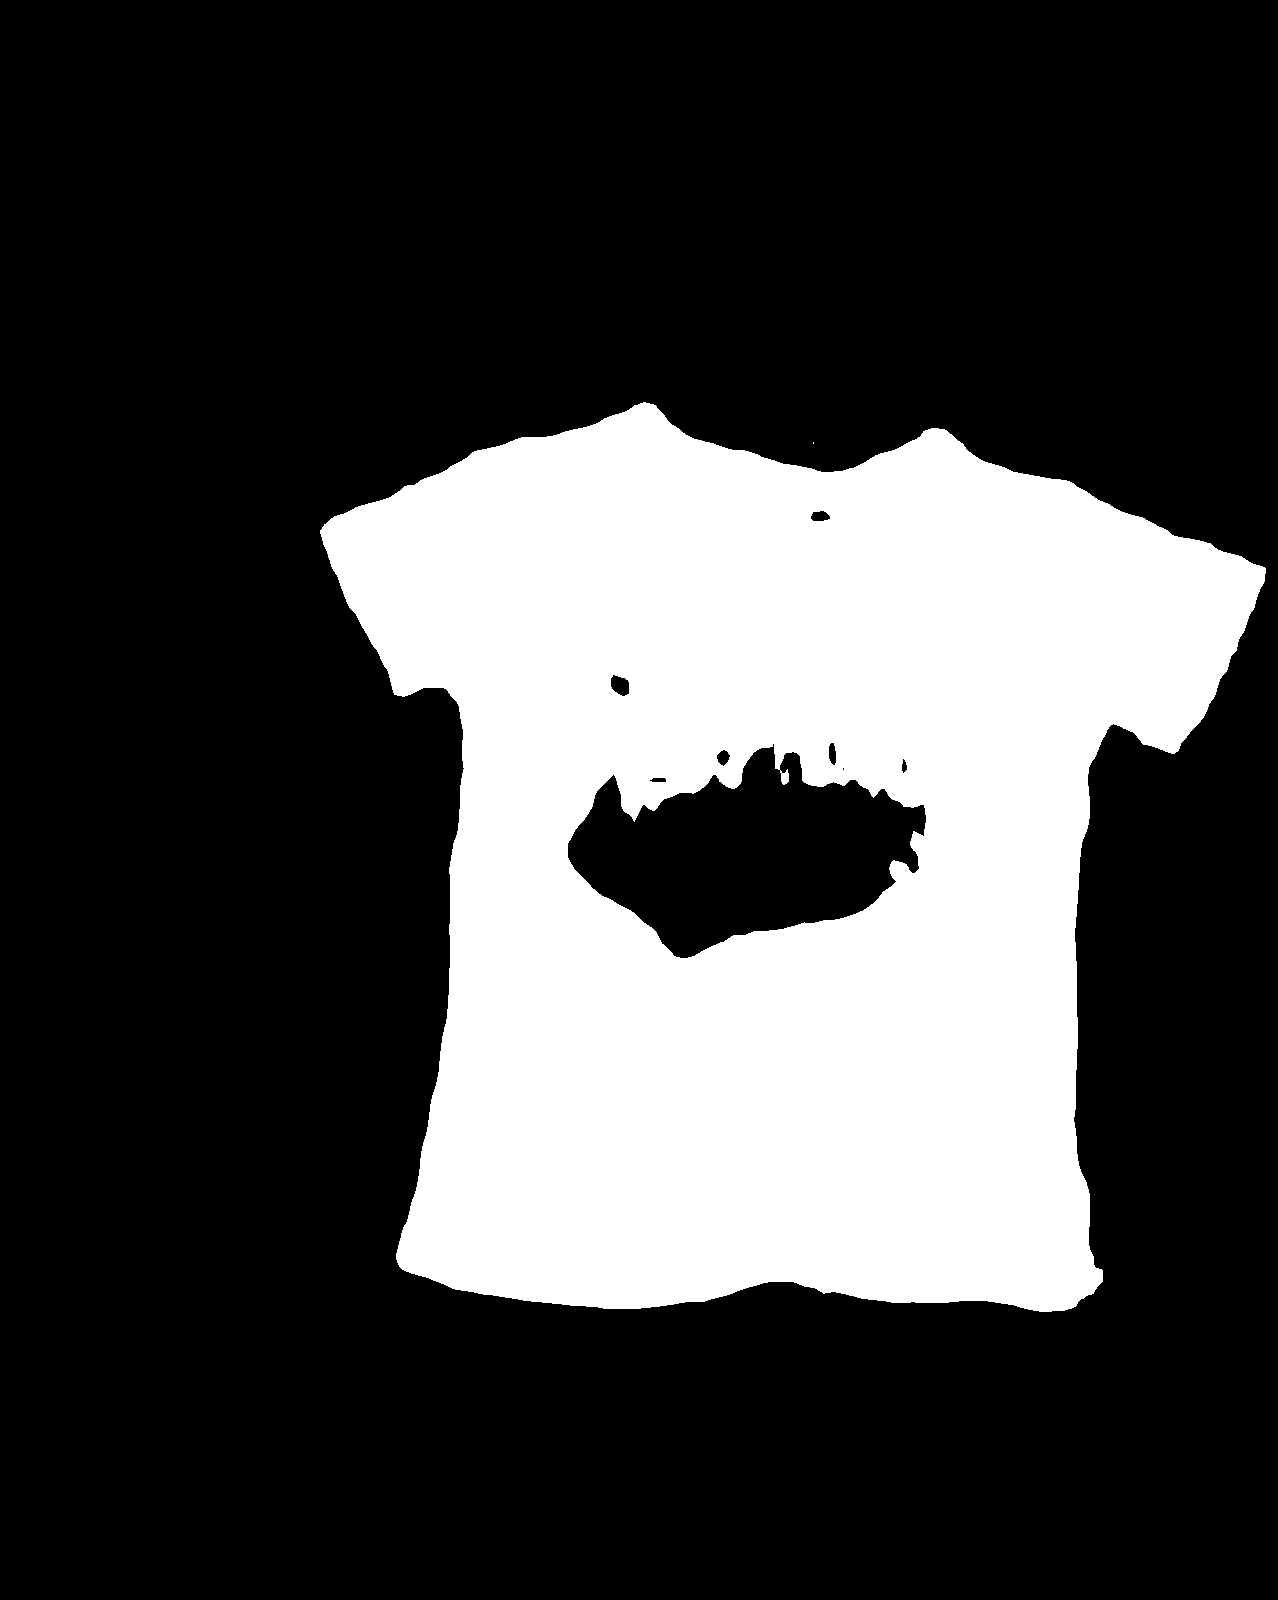

In [29]:
import numpy as np

garment_mask = None
for s in segments:
    if s['label'] in ["Dress", "Upper-clothes"]:
        garment_mask = s['mask']

garment_mask

In [30]:
cv2.namedWindow("Select the A4 sheet, then press ENTER", cv2.WINDOW_NORMAL)
r = cv2.selectROI("Select the A4 sheet, then press ENTER", image_cv, showCrosshair=True)
cv2.destroyAllWindows()

x, y, w, h = r
print("Selected A4 region (x, y, width, height):", r)

Selected A4 region (x, y, width, height): (32, 714, 342, 435)


In [31]:
x, y, w, h = r  # from your manual selection

pixels_per_cm = max(w, h) / 29.7

print("Pixels per cm:", pixels_per_cm)

Pixels per cm: 14.646464646464647


In [32]:
mask_array = np.array(garment_mask)

ys, xs = np.where(mask_array > 0)

chest_width_px = xs.max() - xs.min()

length_px = ys.max() - ys.min()

chest_width_cm = chest_width_px / pixels_per_cm
length_cm = length_px / pixels_per_cm

print("Estimated chest width (cm):", chest_width_cm)
print("Estimated length (cm):", length_cm)

Estimated chest width (cm): 64.5206896551724
Estimated length (cm): 62.06275862068965


In [33]:
mask_uint8 = (mask_array > 0).astype(np.uint8) * 255
total_pixels = np.sum(mask_uint8 > 0)

kernel_size = 15
clean_mask = None

while kernel_size <= 60:
    kernel = np.ones((kernel_size, kernel_size), np.uint8)
    merged = cv2.morphologyEx(mask_uint8, cv2.MORPH_CLOSE, kernel)
    
    num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(merged, connectivity=8)
    largest_label = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
    largest_area = stats[largest_label, cv2.CC_STAT_AREA]
    
    if largest_area >= total_pixels * 0.9:
        keep_region = (labels == largest_label).astype(np.uint8)
        clean_mask = ((mask_array > 0).astype(np.uint8)) * keep_region
        print(f"Solved at kernel size {kernel_size}")
        break
    
    kernel_size += 5

ys, xs = np.where(clean_mask > 0)
print("Cleaned mask - garment pixel count:", len(xs))

Solved at kernel size 15
Cleaned mask - garment pixel count: 551797


In [34]:
top_y = ys.min()
bottom_y = ys.max()
garment_height = bottom_y - top_y

widths = []

for pct in np.arange(0.20, 0.50, 0.01):
    row = top_y + int(garment_height * pct)
    row_xs = xs[ys == row]
    if len(row_xs) > 0:
        widths.append(row_xs.max() - row_xs.min())

widths_sorted = sorted(widths)
narrowest_few = widths_sorted[:5]  # take the 5 narrowest rows
chest_width_px = np.median(narrowest_few)

chest_width_cm = chest_width_px / pixels_per_cm
print("Auto-detected chest width (cm):", chest_width_cm)

Auto-detected chest width (cm): 42.74068965517241


In [35]:
length_px = ys.max() - ys.min()
length_cm = length_px / pixels_per_cm
print("Cleaned length (cm):", length_cm)

Cleaned length (cm): 62.06275862068965


In [36]:
actual_chest = 44
correction_factor = actual_chest / chest_width_cm
print("Correction factor:", correction_factor)

Correction factor: 1.0294639687610934
